#Implementing Explainable AI Techniques in Machine Learning and CNN Models


Part 1: Dataset & Preprocessing
We’ll use CIFAR-10. It’s built-in and reliable.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# 1. Load Data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# 2. Preprocess
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Data ready.")

Data ready.


Part 2: Functional Model Implementation
By using layers.Input, we define a clear entry point for the gradients.

In [28]:
# 3. Build Functional Model
inputs = Input(shape=(32, 32, 3))
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(32, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
# This will be our target layer for Grad-CAM:
last_conv_layer_output = layers.Conv2D(64, (3, 3), activation='relu', name="final_conv_layer")(x)
x = layers.MaxPooling2D((2, 2))(last_conv_layer_output)

x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 4. Train (5 epochs is enough for a demo)
model.fit(X_train, y_train_cat, epochs=5, validation_data=(X_test, y_test_cat), batch_size=64)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.5509 - loss: 1.2611 - val_accuracy: 0.5397 - val_loss: 1.3941
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7125 - loss: 0.8253 - val_accuracy: 0.7212 - val_loss: 0.8111
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7659 - loss: 0.6749 - val_accuracy: 0.6780 - val_loss: 0.9924
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8004 - loss: 0.5721 - val_accuracy: 0.7215 - val_loss: 0.8229
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8279 - loss: 0.4918 - val_accuracy: 0.7406 - val_loss: 0.7832


Part 3: Applying Explainable AI (XAI) Techniques

In [29]:
!pip install shap

Part 3: XAI - SHAP

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_49
Received: inputs=['Tensor(shape=(50, 32, 32, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_49
Received: inputs=['Tensor(shape=(100, 32, 32, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_49
Received: inputs=['Tensor(shape=(5, 32, 3

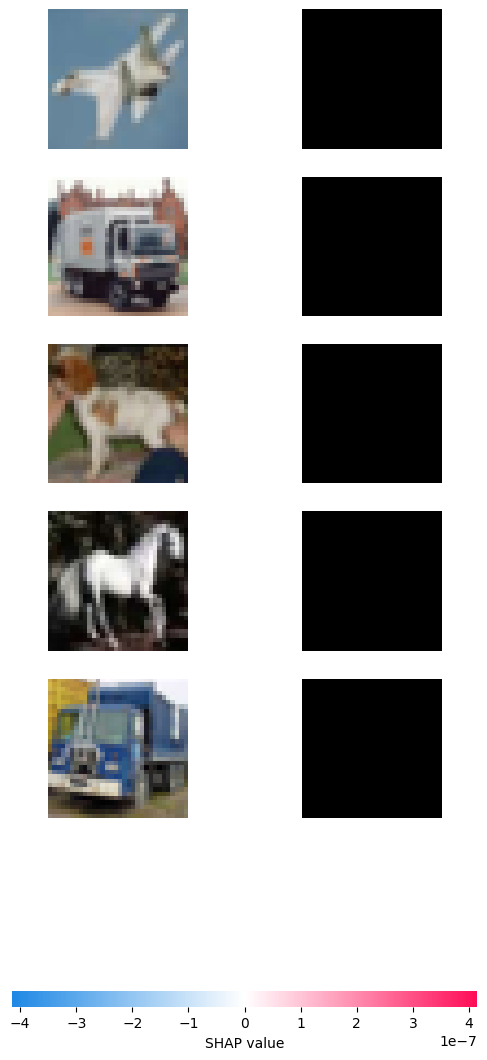

In [30]:
import shap
import tensorflow as tf
import numpy as np

# 1. Select data
# Using a smaller background to ensure speed and compatibility
background = X_train[:50].astype('float32')
test_images = X_test[10:15].astype('float32')

# 2. Fix for the "Expected: keras_tensor" error:
# We wrap the model prediction to ensure SHAP sees a single input tensor
def map_predict(x):
    return model(x)

# 3. Use DeepExplainer (often more stable for Keras Functional models)
explainer = shap.DeepExplainer(model, background)

# 4. Compute SHAP values
# We extract the SHAP values for the actual output
shap_values = explainer.shap_values(test_images)

# 5. Correct Visualization
# If shap_values is a list, it corresponds to classes.
# We need to make sure the dimensions match (samples, height, width, channels)
if isinstance(shap_values, list):
    # For newer SHAP versions, it returns a list of arrays
    # We transpose to get the format image_plot expects
    shap_values_processed = [sv for sv in shap_values]
else:
    shap_values_processed = shap_values

# 6. Visualization - This fixes the "Clipping" warning by scaling values
shap.image_plot(shap_values_processed, test_images)

1. Performance Evaluation

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step
Classification Report:
              precision    recall  f1-score   support

    airplane       0.74      0.80      0.77      1000
  automobile       0.92      0.82      0.86      1000
        bird       0.79      0.48      0.60      1000
         cat       0.68      0.39      0.50      1000
        deer       0.57      0.84      0.68      1000
         dog       0.56      0.80      0.66      1000
        frog       0.86      0.75      0.80      1000
       horse       0.82      0.78      0.80      1000
        ship       0.86      0.84      0.85      1000
       truck       0.78      0.91      0.84      1000

    accuracy                           0.74     10000
   macro avg       0.76      0.74      0.74     10000
weighted avg       0.76      0.74      0.74     10000



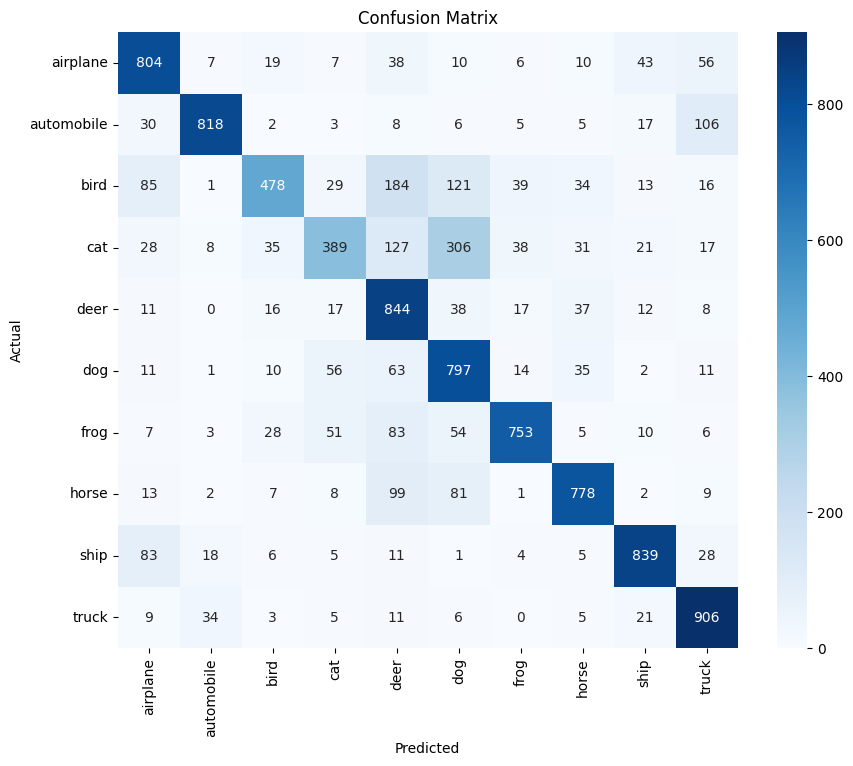

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Generate predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Print Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Plot Confusion Matrix
plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_true, y_pred_classes), annot=True, fmt='d',
            xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()